# 1.3. Статический расчет: реакции и внутренние усилия

### Beam.load

`property load`

Возвращает выражение в виде сингулярной функции, представляющее кривую распределения нагрузки для объекта балки.

#### Пример

Имеется балка длиной 4 метра. В начальной точке балки приложен момент величиной 3 Нм, действующий по часовой стрелке. Сосредоточенная сила величиной 4 Н приложена к верхней точке балки на расстоянии 2 метров от начала, и параболическая линейно возрастающая нагрузка величиной 2 Н/м приложена снизу балки, начиная с расстояния 3 метра от начальной точки балки.

In [18]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
b = Beam(4, E, I)
b.apply_load(-3, 0, -2)
b.apply_load(4, 2, -1)
b.apply_load(-2, 3, 2)
b.load

-3*SingularityFunction(x, 0, -2) + 4*SingularityFunction(x, 2, -1) - 2*SingularityFunction(x, 3, 2)

### Beam.applied_loads

`property applied_loads` - возвращает список всех нагрузок, приложенных к объекту балки. Каждая нагрузка в списке представлена в виде кортежа.

#### Пример. Вывести список всех приложенных нагрузок на балку.

Есть балка длиной 4 метра. В начале балки приложен момент величиной 3 Н·м по часовой стрелке. В верхней части балки на расстоянии 2 метра от начала приложена точечная нагрузка величиной 4 Н. Другая точечная нагрузка величиной 5 Н приложена в том же месте.

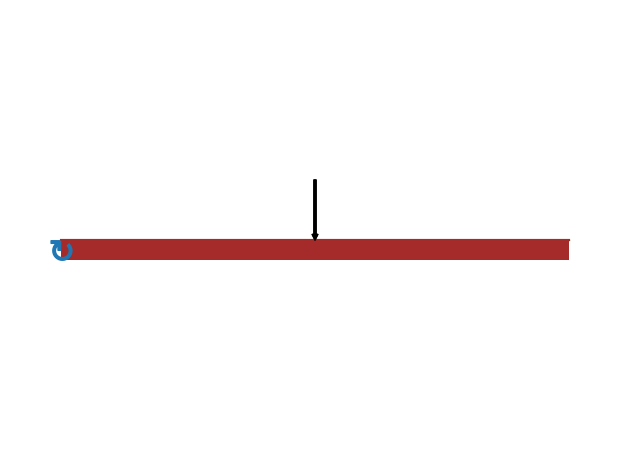

In [19]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
b = Beam(4, E, I)
b.apply_load(-3, 0, -2)
b.apply_load(4, 2, -1)
b.apply_load(5, 2, -1)
p = b.draw()
p.show()

In [20]:
b.load

-3*SingularityFunction(x, 0, -2) + 9*SingularityFunction(x, 2, -1)

In [21]:
b.applied_loads

[(-3, 0, -2, None), (4, 2, -1, None), (5, 2, -1, None)]

### Beam.solve_for_reaction_loads()

`solve_for_reaction_loads()`

Решает задачу по определению опорных реакций.

#### Пример

Имеется балка длиной 30 метров. На конце балки приложен момент величиной 120 Н·м, действующий по часовой стрелке. В начальной точке к балке сверху приложена сосредоточенная сила величиной 8 Н. Под балкой расположены две шарнирные опоры. Одна на конце, другая на расстоянии 10 метров от начала. На обеих опорах ограничены перемещения (прогибы).

Принято правило знаков: направленные вверх силы и момент по часовой стрелке считаются положительными.

In [22]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
R1, R2 = symbols('R1, R2')
b = Beam(30, E, I)
b.apply_load(-8, 0, -1)
b.apply_load(R1, 10, -1)  # Reaction force at x = 10
b.apply_load(R2, 30, -1)  # Reaction force at x = 30
b.apply_load(120, 30, -2)
b.bc_deflection = [(10, 0), (30, 0)]
b.load

R1*SingularityFunction(x, 10, -1) + R2*SingularityFunction(x, 30, -1) - 8*SingularityFunction(x, 0, -1) + 120*SingularityFunction(x, 30, -2)

In [23]:
b.solve_for_reaction_loads(R1, R2)
b.reaction_loads

{R1: 6, R2: 2}

In [24]:
b.load

-8*SingularityFunction(x, 0, -1) + 6*SingularityFunction(x, 10, -1) + 120*SingularityFunction(x, 30, -2) + 2*SingularityFunction(x, 30, -1)

### Beam.reaction_loads

`property reaction_loads`

Возвращает опорные реакции в виде словаря.

### Beam.shear_force()

`shear_force()`

Возвращает выражение в виде сингулярной функции, представляющее кривую поперечной силы для объекта «Балка».

#### Пример

Имеется балка длиной 30 метров. Момент величиной 120 Н·м приложен по часовой стрелке на конце балки. Сосредоточенная сила величиной 8 Н приложена сверху балки в её начале. Под балкой расположены две простые опоры. Одна на конце, другая на расстоянии 10 метров от начала. Прогиб ограничен на обеих опорах.

Используется правило знаков: силы, направленные вверх, и момент по часовой стрелке считаются положительными.

In [25]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
R1, R2 = symbols('R1, R2')
b = Beam(30, E, I)
b.apply_load(-8, 0, -1)
b.apply_load(R1, 10, -1)
b.apply_load(R2, 30, -1)
b.apply_load(120, 30, -2)
b.bc_deflection = [(10, 0), (30, 0)]
b.solve_for_reaction_loads(R1, R2)
b.shear_force()

8*SingularityFunction(x, 0, 0) - 6*SingularityFunction(x, 10, 0) - 120*SingularityFunction(x, 30, -1) - 2*SingularityFunction(x, 30, 0)

### Beam.shear_stress()

`shear_stress()`

Возвращает выражение, представляющее кривую касательных напряжений для объекта «Балка».

#### Пример

Имеется балка длиной 30 метров. На конце балки приложен момент величиной 120 Нм, действующий по часовой стрелке. Сосредоточенная сила величиной 8 Н приложена к верхней точке балки в ее начале. Под балкой расположены две простые опоры. Одна на конце, другая на расстоянии 10 метров от начала. Прогиб ограничен на обеих опорах.

Используется правило знаков: положительными считаются силы, направленные вверх, и момент, действующий по часовой стрелке.

### Beam.bending_moment()
Возвращает выражение в виде сингулярной функции, представляющее кривую изгибающего момента для объекта балки.

In [26]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
R1, R2 = symbols('R1, R2')
b = Beam(30, E, I)
b.apply_load(-8, 0, -1)
b.apply_load(R1, 10, -1)
b.apply_load(R2, 30, -1)
b.apply_load(120, 30, -2)
b.bc_deflection = [(10, 0), (30, 0)]
b.solve_for_reaction_loads(R1, R2)

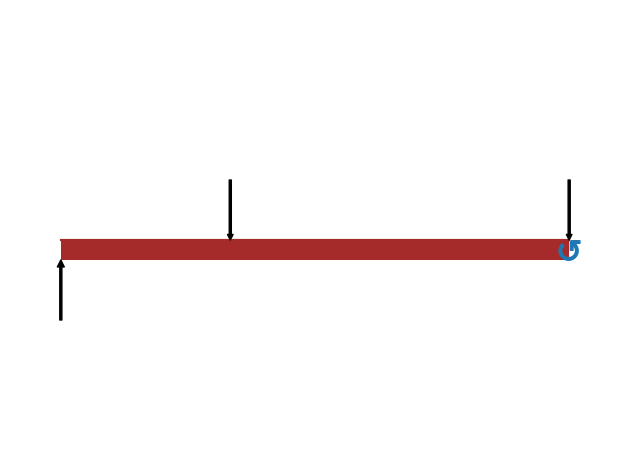

In [27]:
p = b.draw()
p.show()

In [28]:
b.bending_moment()

8*SingularityFunction(x, 0, 1) - 6*SingularityFunction(x, 10, 1) - 120*SingularityFunction(x, 30, 0) - 2*SingularityFunction(x, 30, 1)

### Beam.point_cflexure()

`point_cflexure()`

Возвращает множество точек с нулевым изгибающим моментом, в которых эпюра изгибающих моментов меняет знак с отрицательного на положительный или наоборот.

#### Пример

Имеется консольная балка длиной 10 метров с вылетом. Под балкой расположены две простые опоры. Одна в начале, другая — на расстоянии 6 метров от начала. Сосредоточенные силы величиной 10 кН и 20 кН приложены на расстоянии 2 и 4 метра от начала соответственно. Равномерно распределённая нагрузка величиной 3 кН/м также приложена сверху, начиная с 6 метров от начала и до конца балки. Используется правило знаков: силы, направленные вверх, и момент по часовой стрелке считаются положительными.

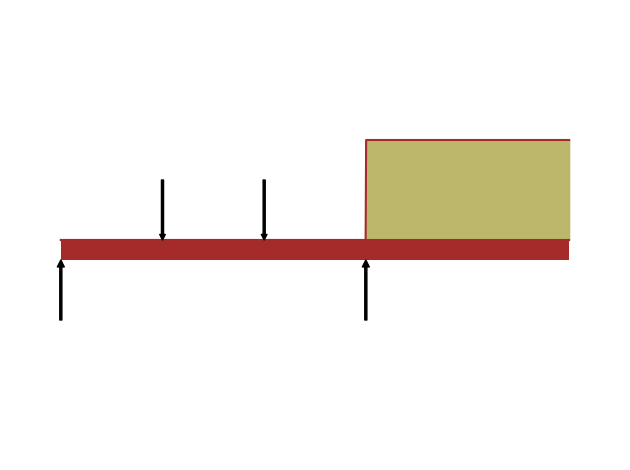

In [29]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
b = Beam(10, E, I)
b.apply_load(-4, 0, -1)
b.apply_load(-46, 6, -1)
b.apply_load(10, 2, -1)
b.apply_load(20, 4, -1)
b.apply_load(3, 6, 0)
p = b.draw()
p.show()

In [30]:
b.point_cflexure()

[10/3]

### Beam.max_shear_force()

`max_shear_force()`

Возвращает максимальную поперечную силу и её координату.

In [31]:
b.max_shear_force()

(Interval(4, 6), 26)

### Beam.max_bmoment()

`max_bmoment()`

Возвращает максимальную поперечную силу и ее координату для объекта балки.

In [32]:
b.max_bmoment()

(6, 56)